In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Nitrogen tetroxide, three questions about one reaction (Illustrations 13.1-1, 13.1-2 and 13.1-3, Figures 13.1-3 and 13.1-4)

$$\mathrm{N_2O_4(g)}\;\rightleftharpoons\;2\,\mathrm{NO_2(g)}$$

One reaction, one equilibrium constant, and three separate questions about it. Section 13.1
asks them in a deliberate order, and the order is the lesson:

| | the question | what it isolates |
|---|---|---|
| **13.1-1** | how far does *pure* N$_2$O$_4$ dissociate at 25 °C and 1 bar? | the equilibrium relation on its own |
| **13.1-2** | what if it is diluted to 20 % with nitrogen, which does not react? | that an **inert** changes the answer |
| **13.1-3** | what happens over 200 to 400 K at 0.1, 1 and 10 bar? | that $K_a$ carries the temperature, and $\Delta\nu$ carries the pressure |

$K_a$ is identical in all three -- it depends only on temperature and the choice of
standard state. Everything that differs between them happens on the composition side of
the equation. Keeping them in one notebook is what makes that visible.

Because $\Delta\nu = +1$ here, this reaction runs the *opposite* way from ammonia
synthesis: raising the pressure suppresses it. And because $\Delta_{\rm rxn}H^{\circ}$ is
positive it is endothermic, so raising the temperature promotes it. Figure 13.1-4 is those
two sentences drawn.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.reaction import Reaction, equilibrium_extent
from thermo.charts import use_book_style, label_at

use_book_style()

n2o4 = Reaction.parse("N2O4 = 2 NO2").check_balance()
print(f"reaction: {n2o4.equation}      dnu = {n2o4.delta_nu:+g}")
print(f"species:  {', '.join(n2o4.species)}")

reaction: N2O4 = 2 NO2      dnu = +1
species:  N2O4, NO2


## The equilibrium constant, once, for all three illustrations

$\Delta_{\rm rxn}G^{\circ}$ and $\Delta_{\rm rxn}H^{\circ}$ at 25 °C come from Appendix
A.IV, and $\Delta_{\rm rxn}C_P^{*}$ from Appendix A.II. **Read the precision of the
appendix carefully**: A.IV tabulates these two species to one decimal in kJ/mol, and that
one digit is worth 1.2 % in $K_a$ here -- enough to move the third figure of every extent
below. The notebook uses the appendix as printed and says what it got.

In [3]:
T_REF = 298.15

print(n2o4.table([T_REF]).to_string(index=False))
Ka25 = float(n2o4.Ka(T_REF))
print(f"\nKa(25 C) = {Ka25:.4f}")
print(f"dG_rxn(25 C) = {float(n2o4.delta_G_ref):.0f} J/mol"
      f"     dH_rxn(25 C) = {float(n2o4.delta_H_ref):.0f} J/mol")

# Endothermic, and delta_nu positive: the two facts that set the sign of every trend below.
assert float(n2o4.delta_H_ref) > 0
assert n2o4.delta_nu > 0

 T (K)     ln Ka  log10 Ka       Ka  dG_rxn (kJ/mol)  dH_rxn (kJ/mol)
298.15 -1.895959 -0.823404 0.150174              4.7             57.2

Ka(25 C) = 0.1502
dG_rxn(25 C) = 4700 J/mol     dH_rxn(25 C) = 57200 J/mol


## Illustration 13.1-1 -- pure nitrogen tetroxide

The mass balance is the whole calculation. `balance_table` writes it symbolically, exactly
as the illustration does, so the algebra can be checked against the printed table rather
than trusted.

In [4]:
print(n2o4.balance_table({"N2O4": 1.0}).to_string())

pure = equilibrium_extent(n2o4, T_REF, {"N2O4": 1.0}, P=1.0)
print(f"\nX = {pure.X:.4f}     N2O4 is {100*pure.X:.1f} percent decomposed")
for s, v in pure.y.items():
    print(f"  y_{s:5s} = {v:.4f}")

# With one reactant and P = 1 bar the relation closes in one line, used here
# as an independent check on the solver rather than as the route.
closed = np.sqrt(Ka25 / (4 + Ka25))
print(f"\nclosed form sqrt(Ka/(4+Ka)) = {closed:.6f}   solver = {pure.X:.6f}")
assert abs(closed - pure.X) < 1e-6

      initial  final    mole fraction
N2O4      1.0  1 - X  (1 - X)/(1 + X)
NO2       0.0    2 X    (2 X)/(1 + X)
Total     1.0  1 + X                1

X = 0.1902     N2O4 is 19.0 percent decomposed
  y_N2O4  = 0.6804
  y_NO2   = 0.3196

closed form sqrt(Ka/(4+Ka)) = 0.190224   solver = 0.190224


## Illustration 13.1-2 -- what an inert diluent does, and why

Now 0.2 mol of N$_2$O$_4$ in 0.8 mol of nitrogen, still at 25 °C and 1 bar. The nitrogen
takes no part in the reaction and does not appear in $K_a$ -- and the dissociation goes
*further* anyway.

The illustration's Comment gives the reason in one sentence, restated here as an
inequality. Diluting divides $y_{\rm NO_2}$ and $y_{\rm N_2O_4}$ by the same factor, but
$y_{\rm NO_2}$ enters $K_a$ **squared** and $y_{\rm N_2O_4}$ only to the first power, so the
ratio $y_{\rm NO_2}^2/y_{\rm N_2O_4}$ falls -- and the reaction must move right to restore
it. **The exponent that matters is $\Delta\nu$**, and it is the same $\Delta\nu$ that makes
pressure act on this reaction at all.

In [5]:
print(n2o4.balance_table({"N2O4": 0.2, "N2": 0.8}).to_string())

dil = equilibrium_extent(n2o4, T_REF, {"N2O4": 0.2, "N2": 0.8}, P=1.0)
print(f"\nX = {dil.X:.4f}")
for s, v in dil.y.items():
    print(f"  y_{s:5s} = {v:.4f}")

frac_pure = pure.X / 1.0
frac_dil = dil.X / 0.2
print(f"\nfraction of the N2O4 fed that decomposed")
print(f"  undiluted   {frac_pure:.4f}")
print(f"  diluted     {frac_dil:.4f}     {frac_dil/frac_pure:.2f} times as much")
assert frac_dil > frac_pure

# The same argument the other way round: for an association reaction (dnu < 0) an inert
# must SUPPRESS the conversion. 2 NO2 = N2O4 is this reaction reversed, so it is a free
# test of the reasoning rather than a new calculation.
assoc = n2o4.reversed()
a_pure = equilibrium_extent(assoc, T_REF, {"NO2": 1.0}, P=1.0)
a_dil = equilibrium_extent(assoc, T_REF, {"NO2": 0.2, "N2": 0.8}, P=1.0)
print(f"\nreversed reaction {assoc.equation} (dnu = {assoc.delta_nu:+g}), fraction of NO2 reacted")
print(f"  undiluted   {2*a_pure.X/1.0:.4f}")
print(f"  diluted     {2*a_dil.X/0.2:.4f}     an inert now HURTS, as the sign of dnu requires")
assert 2*a_dil.X/0.2 < 2*a_pure.X/1.0

      initial    final      mole fraction
N2O4      0.2  0.2 - X  (0.2 - X)/(1 + X)
N2        0.8      0.8      (0.8)/(1 + X)
NO2       0.0      2 X      (2 X)/(1 + X)
Total     1.0    1 + X                  1

X = 0.0718
  y_N2O4  = 0.1196
  y_N2    = 0.7464
  y_NO2   = 0.1340

fraction of the N2O4 fed that decomposed
  undiluted   0.1902
  diluted     0.3591     1.89 times as much

reversed reaction 2 NO2 = N2O4 (dnu = -1), fraction of NO2 reacted
  undiluted   0.8098
  diluted     0.5560     an inert now HURTS, as the sign of dnu requires


## Illustration 13.1-3 and Figure 13.1-3 -- carrying $K_a$ from 25 °C to 200-400 K

$\Delta_{\rm rxn}H^{\circ}$ is not constant over 200 K, so $K_a(T)$ comes from
Eq. 13.1-23b with the full heat-capacity polynomial rather than from Eq. 13.1-22b.
`thermo.reaction` integrates it; the coefficients it uses are checked against the ones the
illustration prints in `validation/reaction_module_validation.ipynb`.

**The figure is drawn as two stacked panels rather than on twin axes.** The printed figure drew both
curves against one frame with two arrows to say which curve belonged to which axis; the
arrows were there because the layout was ambiguous. Two panels sharing a temperature axis
need no arrows, and they let each quantity have an axis scaled to its own range -- which is
what shows the point. **$K_a$ moves seven and a half decades over this range;
$\Delta_{\rm rxn}H^{\circ}$ moves 0.9 kJ/mol out of 57.** That is the justification for
treating the heat of reaction as nearly constant while never treating $K_a$ that way.

log10 Ka spans -5.76 to 1.72  (7.5 decades)
dH_rxn spans   56.54 to 57.42 kJ/mol  (1.6 percent)


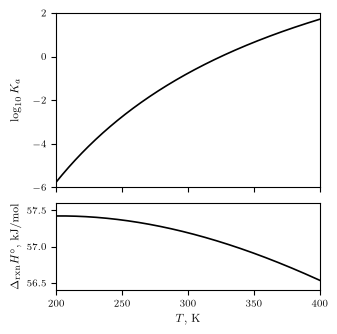

In [6]:
T_GRID = np.linspace(200.0, 400.0, 401)
Ka_T = np.array([float(n2o4.Ka(t)) for t in T_GRID])
dH_T = np.array([float(n2o4.delta_H(t)) for t in T_GRID]) / 1000.0

fig3, (ax_K, ax_H) = plt.subplots(
    2, 1, sharex=True, figsize=(3.4, 3.6),
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.12))

ax_K.plot(T_GRID, np.log10(Ka_T), "-", color="k", lw=1.2)
ax_K.set_ylim(-6, 2)
ax_K.set_yticks(np.arange(-6, 2.1, 2))
ax_K.set_ylabel(r"$\log_{10}K_a$", fontsize=8)

ax_H.plot(T_GRID, dH_T, "-", color="k", lw=1.2)
ax_H.set_ylim(56.4, 57.6)
ax_H.set_yticks(np.arange(56.5, 57.6, 0.5))
ax_H.set_ylabel(r"$\Delta_{\rm rxn}H^{\circ}$, kJ/mol", fontsize=8)

ax_H.set_xlim(200, 400)
ax_H.set_xticks(np.arange(200, 401, 50))
ax_H.set_xlabel(r"$T$, K", fontsize=8)
for a in (ax_K, ax_H):
    a.tick_params(labelsize=7)
fig3.align_ylabels((ax_K, ax_H))

print(f"log10 Ka spans {np.log10(Ka_T).min():.2f} to {np.log10(Ka_T).max():.2f}"
      f"  ({np.log10(Ka_T).max()-np.log10(Ka_T).min():.1f} decades)")
print(f"dH_rxn spans   {dH_T.min():.2f} to {dH_T.max():.2f} kJ/mol"
      f"  ({100*(dH_T.max()-dH_T.min())/dH_T.mean():.1f} percent)")
plt.show()

## Figure 13.1-4 -- extent and mole fraction against temperature and pressure

$K_a$ does not depend on pressure. The *activity ratio* does, because $\Delta\nu = +1$
leaves a factor of $P$ in the equilibrium relation:

$$K_a=\frac{y_{\rm NO_2}^2}{y_{\rm N_2O_4}}\left(\frac{P}{1\ \mathrm{bar}}\right)
\qquad\Longrightarrow\qquad X=\sqrt{\frac{K_a/P}{4+K_a/P}}$$

so the extent depends on $K_a/P$ and nothing else, and raising the pressure at fixed
temperature is *exactly* equivalent to lowering $K_a$ -- which is to say, to cooling. The
three pressure curves are the same curve slid along the temperature axis.

Two quantities are plotted because they are not the same and the difference is easy to
miss: $X$ is per mole of N$_2$O$_4$ fed, while $y_{\rm NO_2}=2X/(1+X)$ is what an analysis
of the gas would report. **$y_{\rm NO_2}$ is always the larger of the two**, and the gap is
widest at half conversion.

The printed version of this figure labels the mole fraction $x_{\rm NO_2}$. It is a gas, so
it is $y$ here.

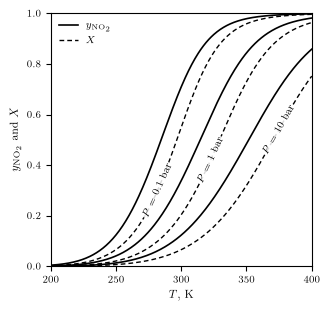

In [7]:
PRESSURES = [0.1, 1.0, 10.0]
X_P, Y_P = {}, {}
for P in PRESSURES:
    X_P[P] = np.array([equilibrium_extent(n2o4, float(t), {"N2O4": 1.0}, P=P).X
                       for t in T_GRID])
    Y_P[P] = 2 * X_P[P] / (1 + X_P[P])

fig4, ax = plt.subplots(figsize=(3.4, 3.2))
for P in PRESSURES:
    ax.plot(T_GRID, Y_P[P], "-", color="k", lw=1.2)
    ax.plot(T_GRID, X_P[P], "--", color="k", lw=1.0, dashes=(3.4, 2.2))

# The pressure labels ride ON their own dashed curve, rotated to it and masked by a white
# box -- `thermo.charts.label_at`, the same device the book's property charts use. The
# three heights are staggered so that three steeply rotated labels never share a band.
for P, height in zip(PRESSURES, (0.30, 0.42, 0.54)):
    placed = label_at(ax, T_GRID, X_P[P], rf"$P$ = {P:g} bar",
                      along="y", value=height, size=7, pad=0.8)
    assert placed, f"the {P} bar label did not land"

ax.set_xlim(200, 400)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(200, 401, 50))
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(labelsize=7)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$y_{\rm NO_2}$ and $X$", fontsize=8)
keys = [plt.Line2D([], [], color="k", lw=1.2, ls="-"),
        plt.Line2D([], [], color="k", lw=1.0, ls="--", dashes=(3.4, 2.2))]
ax.legend(keys, [r"$y_{\rm NO_2}$", r"$X$"], frameon=False, fontsize=7,
          loc="upper left", handlelength=2.0, borderaxespad=0.4)
fig4.tight_layout()
plt.show()

## What the figures show

Six statements, each asserted against the curves rather than described, so that a change in
the appendix data or in the integration cannot invalidate the text beside the art unnoticed.

In [8]:
checks = []
checks.append(("Ka rises with temperature everywhere -- the reaction is endothermic",
               bool(np.all(np.diff(Ka_T) > 0))))
checks.append((f"dH_rxn varies by only {100*(dH_T.max()-dH_T.min())/dH_T.mean():.1f} percent"
               f" while Ka moves {np.log10(Ka_T.max()/Ka_T.min()):.1f} decades",
               (dH_T.max() - dH_T.min()) / dH_T.mean() < 0.02))
checks.append(("the extent rises with temperature at every pressure",
               all(bool(np.all(np.diff(X_P[P]) > 0)) for P in PRESSURES)))
checks.append(("the extent FALLS with pressure at every temperature -- dnu is positive",
               bool(np.all(np.diff(np.array([X_P[P] for P in PRESSURES]), axis=0) < 0))))
checks.append(("y_NO2 exceeds X everywhere, and the gap is widest near half conversion",
               all(bool(np.all(Y_P[P] >= X_P[P])) for P in PRESSURES)))
# X depends on Ka/P alone, so the 1 bar curve at Ka must equal the 10 bar curve at 10 Ka.
scaled = np.sqrt((10 * Ka_T / 10.0) / (4 + 10 * Ka_T / 10.0))
checks.append(("the extent depends on Ka/P alone: the pressure curves are one curve shifted",
               float(np.max(np.abs(scaled - X_P[1.0]))) < 1e-9))
for text, ok in checks:
    print(f"{'holds ' if ok else 'FAILS '}  {text}")
assert all(ok for _, ok in checks)

rows = []
for P in PRESSURES:
    for t in (250.0, 300.0, 350.0):
        i = int(np.argmin(abs(T_GRID - t)))
        rows.append({"P (bar)": P, "T (K)": t, "X": X_P[P][i], "y_NO2": Y_P[P][i]})
print()
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

holds   Ka rises with temperature everywhere -- the reaction is endothermic
holds   dH_rxn varies by only 1.6 percent while Ka moves 7.5 decades
holds   the extent rises with temperature at every pressure
holds   the extent FALLS with pressure at every temperature -- dnu is positive
holds   y_NO2 exceeds X everywhere, and the gap is widest near half conversion
holds   the extent depends on Ka/P alone: the pressure curves are one curve shifted

 P (bar)    T (K)      X  y_NO2
  0.1000 250.0000 0.0660 0.1239
  0.1000 300.0000 0.5496 0.7094
  0.1000 350.0000 0.9587 0.9789
  1.0000 250.0000 0.0209 0.0410
  1.0000 300.0000 0.2037 0.3384
  1.0000 350.0000 0.7294 0.8435
 10.0000 250.0000 0.0066 0.0131
 10.0000 300.0000 0.0656 0.1232
 10.0000 350.0000 0.3195 0.4843


## Staging the art

Both panels are drawn at the size they are printed at -- 3.4 in wide, one column -- so that
7 pt in the notebook is 7 pt on the page.

In [9]:
os.makedirs("pdf", exist_ok=True)
for fig, name in ((fig3, "Figure_13.1-3"), (fig4, "Figure_13.1-4")):
    path = f"pdf/{name}.pdf"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.1-3.pdf


  wrote pdf/Figure_13.1-4.pdf

  typography: LaTeX Computer Modern


## Your turn

1. Illustration 13.1-2's Comment closes with two questions for the reader, and the second
   is the interesting one: **how would an inert diluent affect a reaction with
   $\sum_i\nu_i = 0$?** Pick one -- the water-gas shift, CO + H$_2$O = CO$_2$ + H$_2$, is
   in the database -- and settle it by calculation before you argue it. Then explain the
   result from the form of $K_a$, and say what that implies about running such a reaction
   at pressure.
2. The notebook uses Appendix A.IV as printed: $\Delta_fG^{\circ}$ = 51.3 and 97.9 kJ/mol,
   which give $K_a(25\ ^{\circ}\mathrm{C}) = 0.1502$. Recompute with 51.31 and 97.89 --
   one more digit each -- and report $X$ for both illustrations to four figures. **How many
   figures of $X$ change when one digit is added to each input?** Use the answer to decide
   how many decimals of these numbers can be quoted.
3. Figure 13.1-4 shows that the extent depends on $K_a/P$ alone. Use that: without solving
   anything, find the temperature at 10 bar that gives the same conversion as 250 K at
   0.1 bar. Then check it. What breaks this shortcut if an inert is present?
4. $\Delta_{\rm rxn}H^{\circ}$ falls with temperature here, so $\Delta_{\rm rxn}C_P$ is
   negative -- yet $\Delta\nu = +1$, and adding a mole of gas usually *raises* the heat
   capacity. Look up the two heat capacities and account for the sign. Where does the
   N$_2$O$_4$ polynomial's temperature range end, and what does that mean for the 400 K end
   of these curves?
5. Redraw Figure 13.1-3's top panel as $\ln K_a$ against $1/T$, which is how Sec. 13.1 says
   equilibrium constants are conventionally plotted, and fit a straight line to it. What
   heat of reaction does the slope imply, and how close is it to the mean of the bottom
   panel? That comparison is what Eq. 13.1-22b asserts.
6. At 0.1 bar and 400 K the conversion is 99.6 %, and the dashed and solid curves have
   nearly met. Explain why $X$ and $y_{\rm NO_2}$ must converge as the reaction goes to
   completion, and find the conversion at which the gap between them is largest.